In [4]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import pandas as pd
import numpy as np

# ==============================
# STEP 2: Load Dataset
# ==============================
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Panel Data\Final_Master_Panel_AllColumns.csv")

# ==============================
# STEP 3: Basic Inspection
# ==============================
print(df.head())
print(df.info())
print(df.isnull().sum())

# ==============================
# STEP 4: Fix Population Column (string → numeric)
# ==============================
df['Total_Population'] = df['Total_Population'].astype(str)
df['Total_Population'] = df['Total_Population'].str.replace(',', '')
df['Total_Population'] = df['Total_Population'].astype(float)

# ==============================
# STEP 5: Handle Missing Attacks
# ==============================
df['Attacks'] = df['Attacks'].fillna(0)

# ==============================
# STEP 6: Create Log Attack Variable
# ==============================
df['log_attack'] = np.log1p(df['Attacks'])

# ==============================
# STEP 7: Convert Columns to Numeric (safe)
# ==============================
cols_to_numeric = ['GDP', 'Secondary_Enrollment', 
                   'Poverty_Headcount', 'Unemployment_Rate', 'Inequality_Measure']

for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ==============================
# STEP 8: Create Missing Indicators (IMPORTANT)
# ==============================
df['poverty_missing'] = df['Poverty_Headcount'].isna().astype(int)
df['unemp_missing'] = df['Unemployment_Rate'].isna().astype(int)

# ==============================
# STEP 9: Sort for Panel Interpolation
# ==============================
df = df.sort_values(['Country', 'Year'])

# ==============================
# STEP 10: Interpolate Missing Values (Panel-wise)
# ==============================
df['Poverty_Headcount'] = df.groupby('Country')['Poverty_Headcount'].transform(lambda x: x.interpolate())
df['Unemployment_Rate'] = df.groupby('Country')['Unemployment_Rate'].transform(lambda x: x.interpolate())

# ==============================
# STEP 11: Fill Remaining Missing Values (fallback)
# ==============================
df['Poverty_Headcount'] = df['Poverty_Headcount'].fillna(df['Poverty_Headcount'].mean())
df['Unemployment_Rate'] = df['Unemployment_Rate'].fillna(df['Unemployment_Rate'].mean())

# ==============================
# STEP 12: Handle Inequality (keep but check variation)
# ==============================
if 'Inequality_Measure' in df.columns:
    print("\nInequality unique values:", df['Inequality_Measure'].nunique())

# ==============================
# STEP 13: Drop Rows with Critical Missing Values
# ==============================
df = df.dropna(subset=['GDP', 'Secondary_Enrollment'])

# ==============================
# STEP 14: Log Transform GDP & Population
# ==============================
df['log_gdp'] = np.log(df['GDP'])
df['log_population'] = np.log(df['Total_Population'])

# ==============================
# STEP 15: Final Check
# ==============================
print("\nCleaned Data Info:")
print(df.info())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nPreview Cleaned Data:")
print(df.head())

       Country  Year Country Code  GDP  Attacks Total_Population  \
0  Afghanistan  1970          AFG  NaN      NaN   1,12,90,128.00   
1  Afghanistan  1971          AFG  NaN      NaN   1,15,67,667.00   
2  Afghanistan  1972          AFG  NaN      NaN   1,18,53,696.00   
3  Afghanistan  1973          AFG  NaN      1.0   1,21,57,999.00   
4  Afghanistan  1974          AFG  NaN      NaN   1,24,69,127.00   

   Poverty_Headcount  Secondary_Enrollment  Unemployment_Rate  \
0                NaN               8.36410                NaN   
1                NaN               9.37827                NaN   
2                NaN              10.41424                NaN   
3                NaN              10.93218                NaN   
4                NaN              11.09488                NaN   

   Inequality_Measure  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10545 

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Descriptive Statistics:



c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


           Attacks   log_attack      log_gdp  log_population  \
count  4772.000000  4772.000000  3917.000000     4151.000000   
mean     22.529547     0.950061         -inf       15.491108   
std     115.411177     1.537216          NaN        2.079557   
min       0.000000     0.000000         -inf        8.819074   
25%       0.000000     0.000000     0.937011       14.448189   
50%       0.000000     0.000000     1.477850       15.773001   
75%       3.000000     1.386294     1.895276       16.796971   
max    2215.000000     7.703459     4.416541       21.061606   

       Secondary_Enrollment  Poverty_Headcount  Unemployment_Rate  
count           4772.000000        4772.000000        4772.000000  
mean              64.393945           0.210513           8.353271  
std               35.715942           0.188251           5.612610  
min                0.000000           0.000000           0.039000  
25%               32.805763           0.061655           4.657000  
50%            

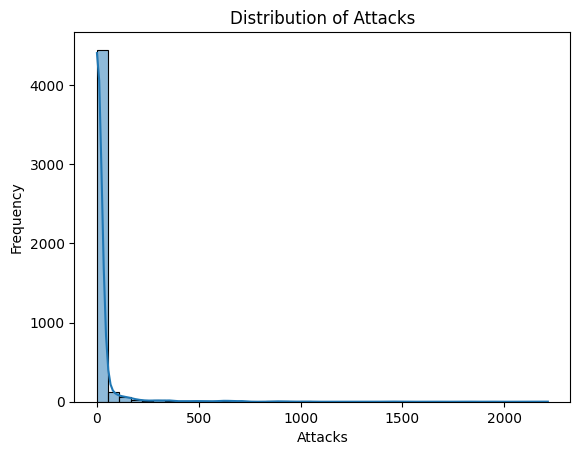

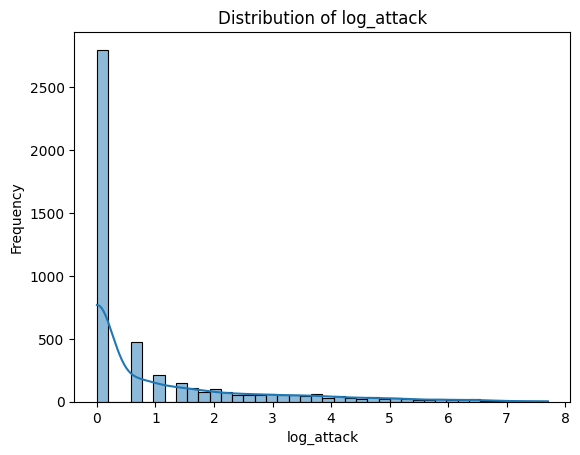

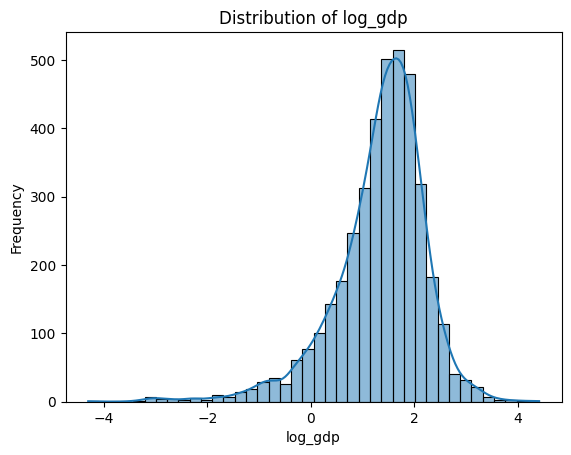

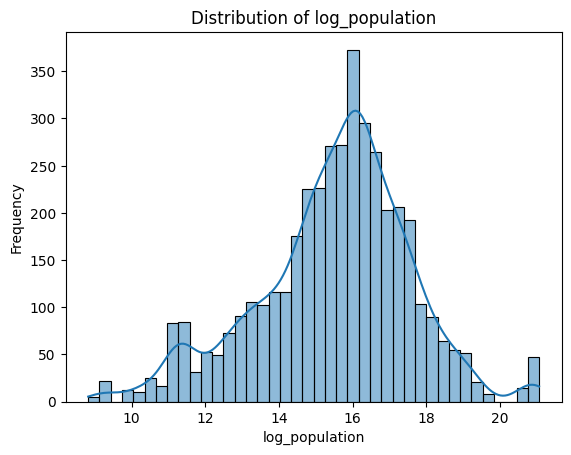

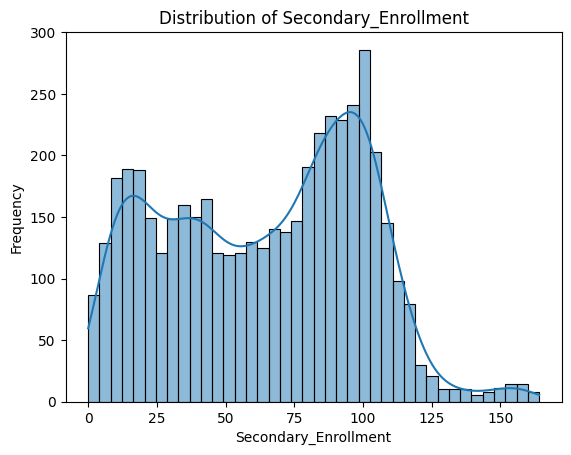

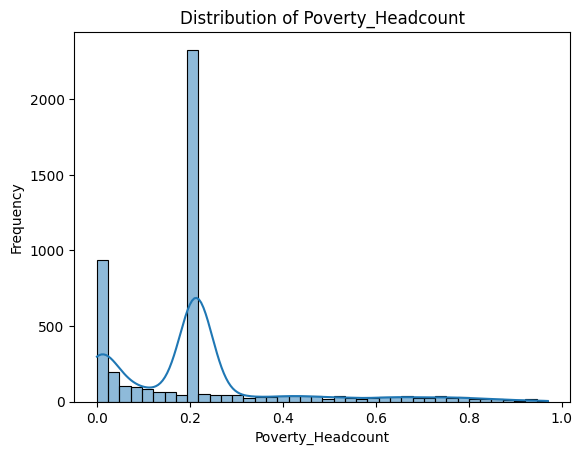

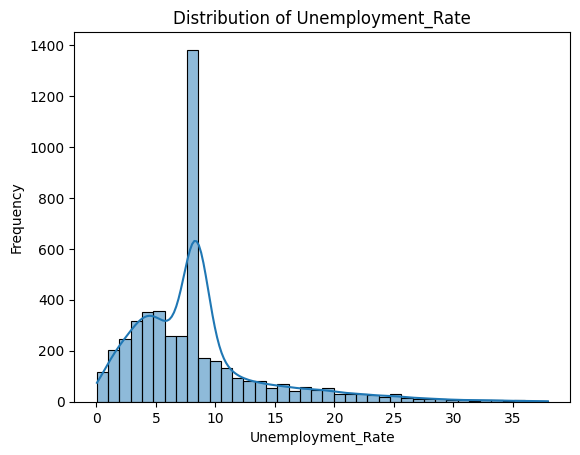

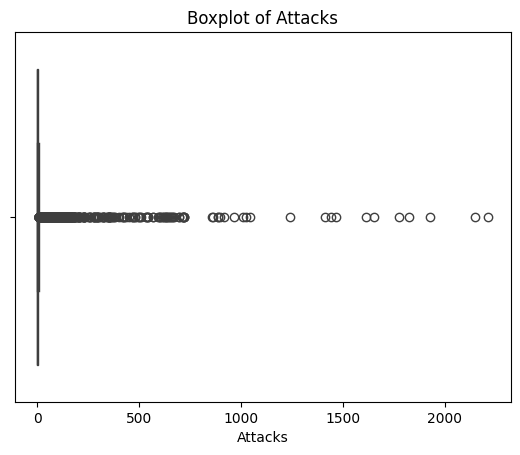

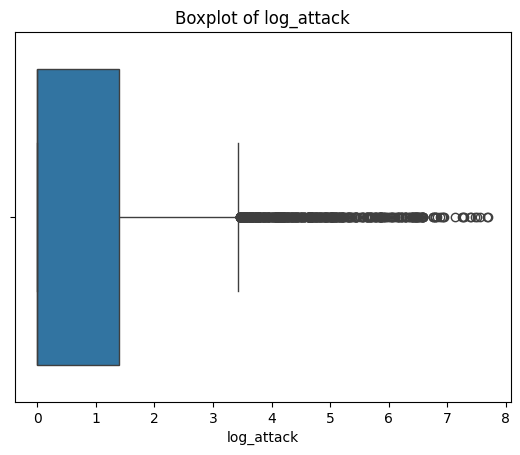

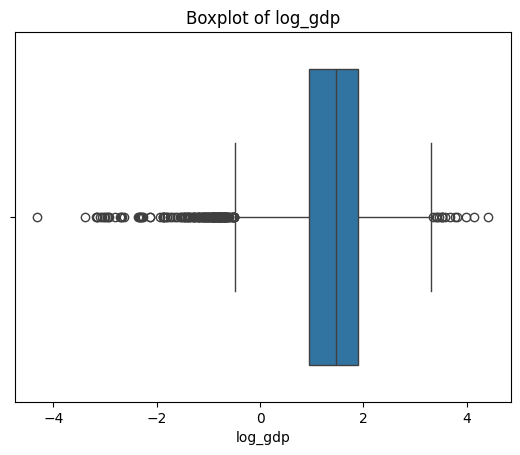

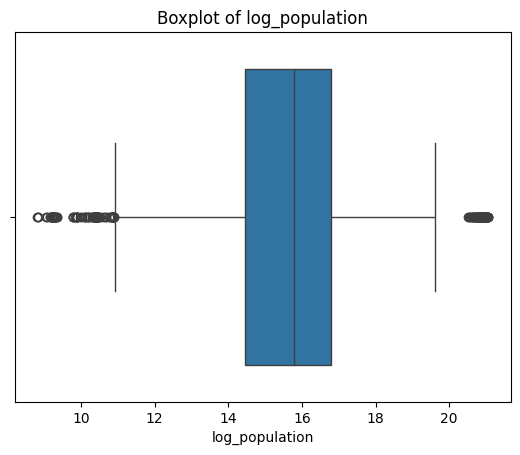

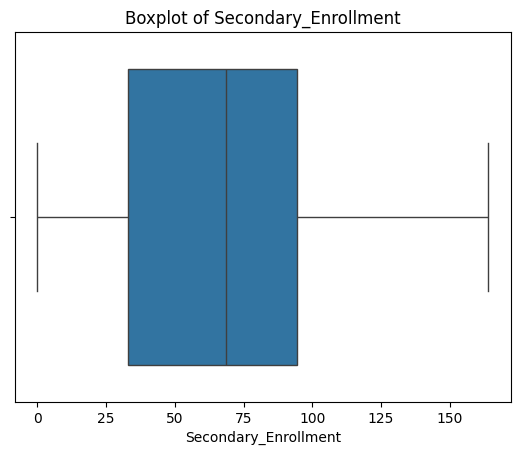

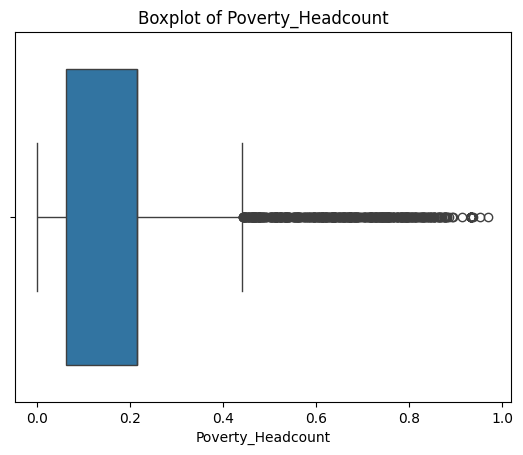

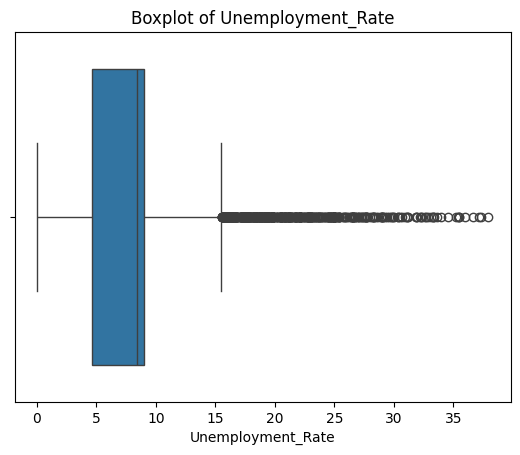

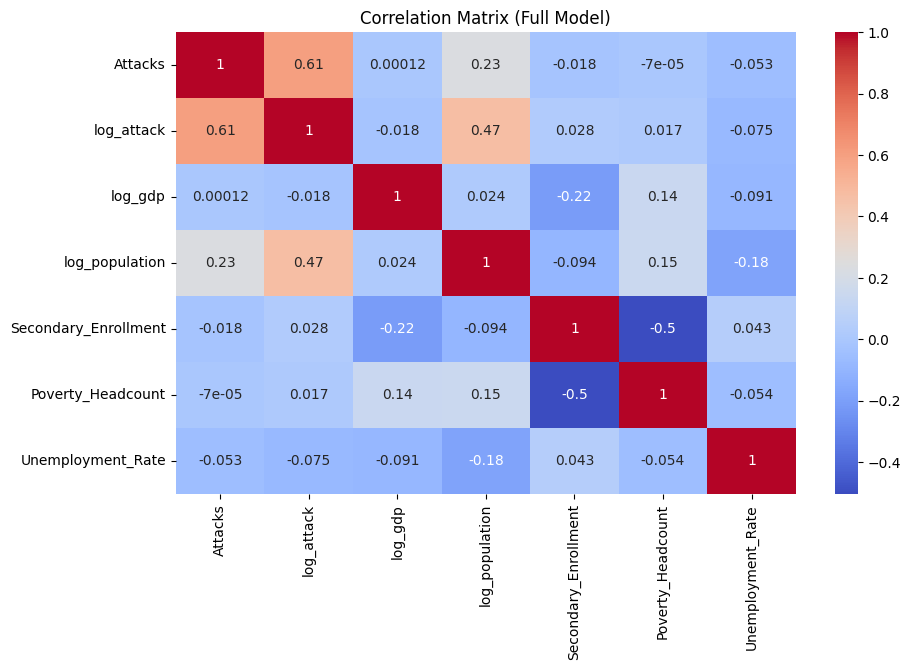

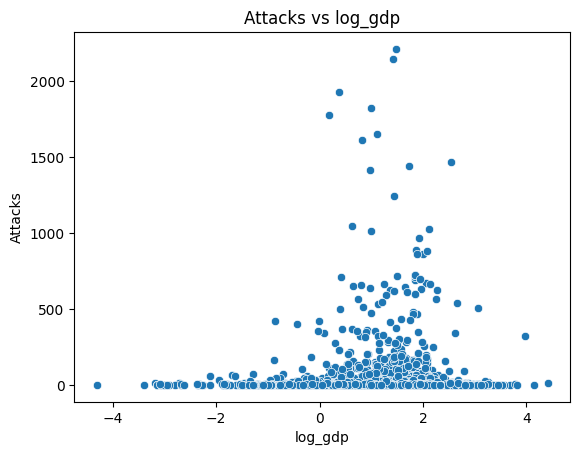

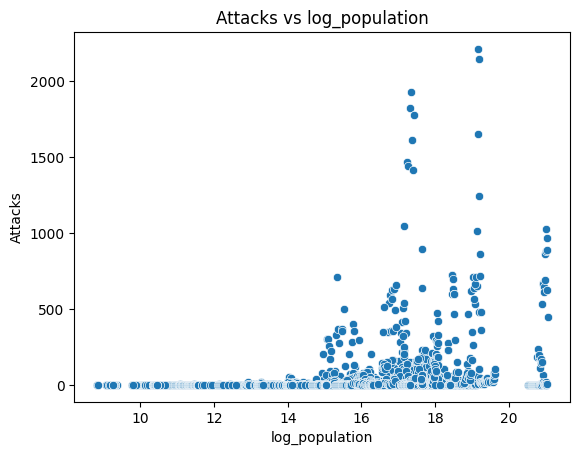

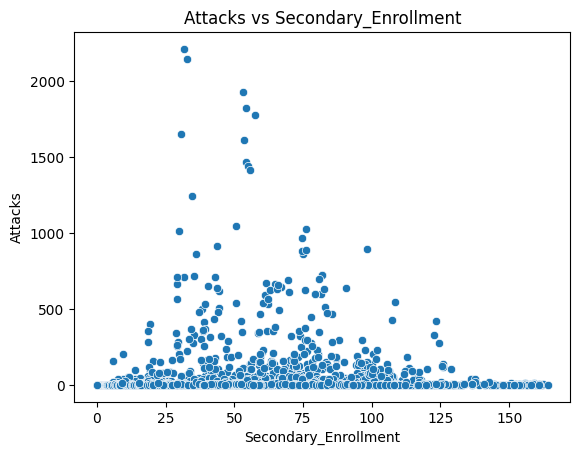

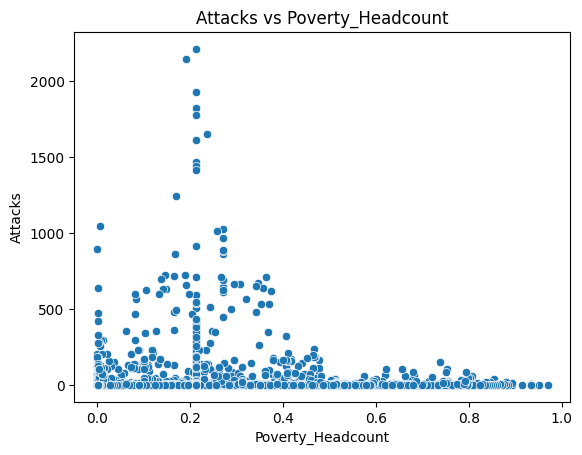

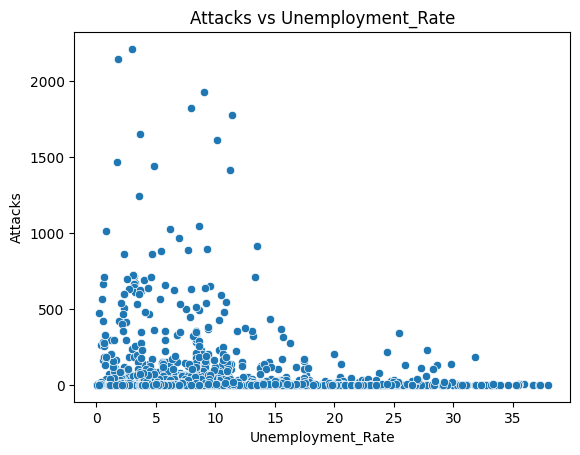

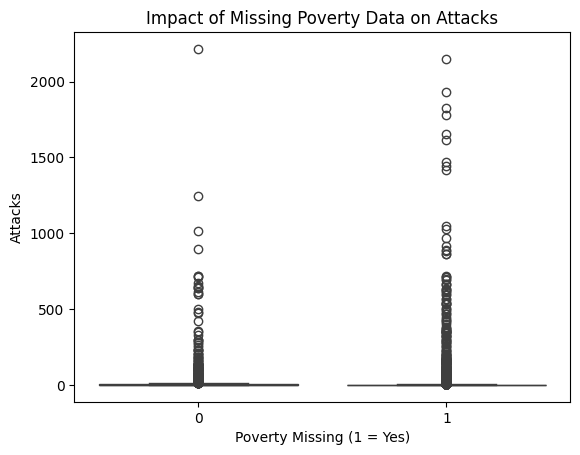

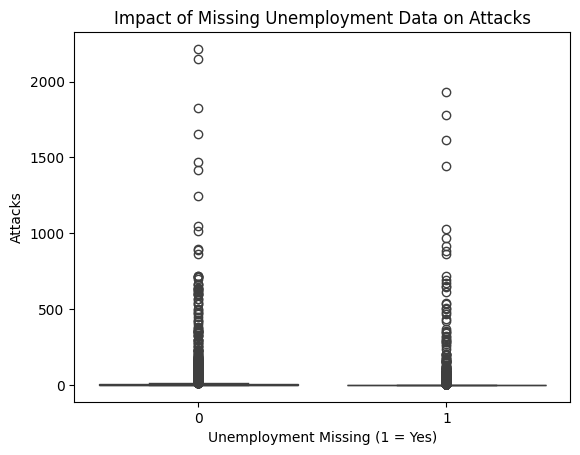

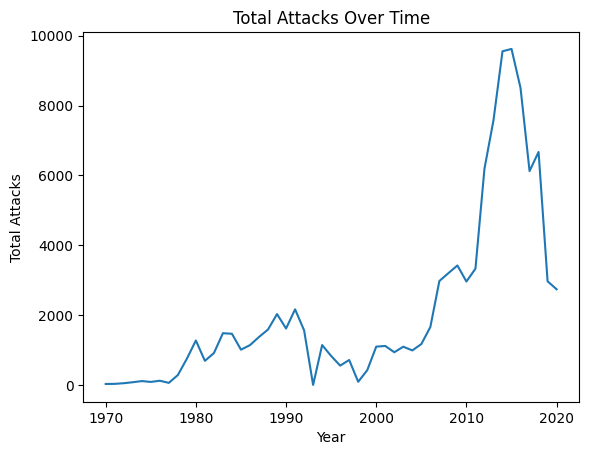

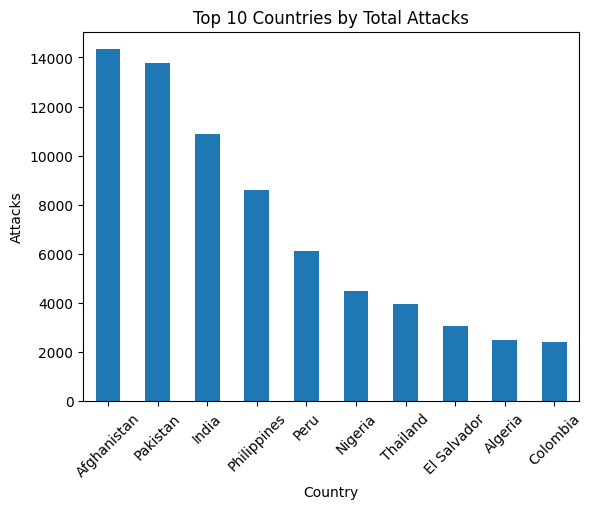

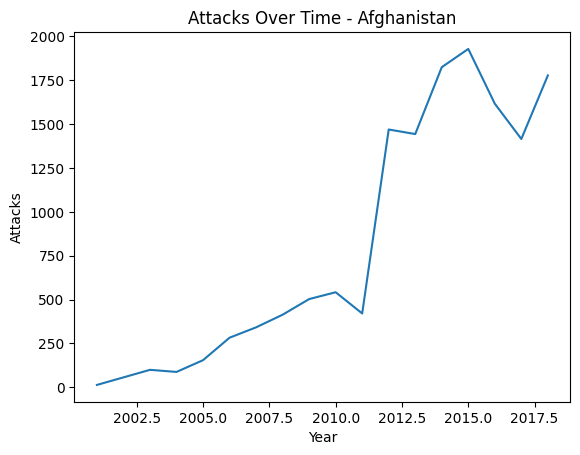

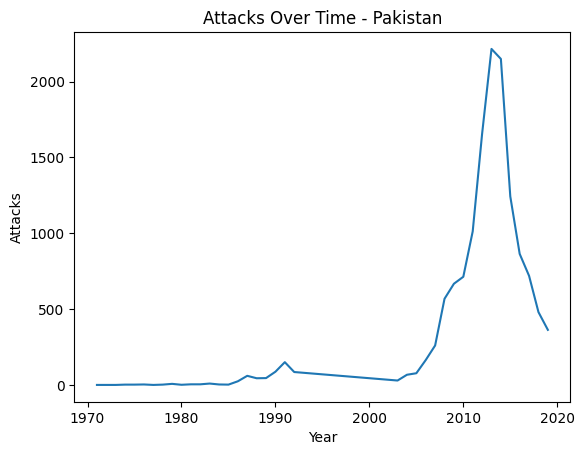

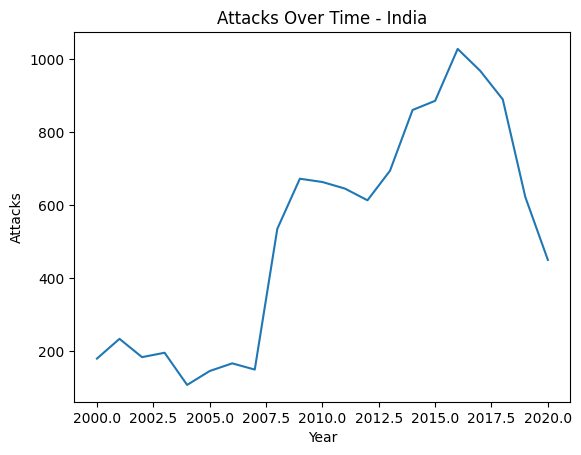

In [5]:
# ==============================
# STEP 1: Descriptive Statistics (UPDATED)
# ==============================
print("Descriptive Statistics:\n")

cols = ['Attacks','log_attack','log_gdp','log_population',
        'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']

print(df[cols].describe())

# ==============================
# STEP 2: Distribution Plots
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

for var in cols:
    plt.figure()
    sns.histplot(df[var], bins=40, kde=True)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

# ==============================
# STEP 3: Boxplots (Outlier Detection)
# ==============================
for var in cols:
    plt.figure()
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot of {var}")
    plt.show()

# ==============================
# STEP 4: Correlation Matrix (FULL)
# ==============================
plt.figure(figsize=(10,6))

corr_matrix = df[['Attacks','log_attack','log_gdp','log_population',
                  'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Full Model)")
plt.show()

# ==============================
# STEP 5: Scatter Plots (Key Relationships)
# ==============================
independent_vars = ['log_gdp','log_population','Secondary_Enrollment',
                    'Poverty_Headcount','Unemployment_Rate']

for var in independent_vars:
    plt.figure()
    sns.scatterplot(x=df[var], y=df['Attacks'])
    plt.title(f"Attacks vs {var}")
    plt.xlabel(var)
    plt.ylabel("Attacks")
    plt.show()

# ==============================
# STEP 6: Missingness Impact (ADVANCED)
# ==============================
# Compare attacks when poverty data was missing vs not

plt.figure()
sns.boxplot(x=df['poverty_missing'], y=df['Attacks'])
plt.title("Impact of Missing Poverty Data on Attacks")
plt.xlabel("Poverty Missing (1 = Yes)")
plt.ylabel("Attacks")
plt.show()

plt.figure()
sns.boxplot(x=df['unemp_missing'], y=df['Attacks'])
plt.title("Impact of Missing Unemployment Data on Attacks")
plt.xlabel("Unemployment Missing (1 = Yes)")
plt.ylabel("Attacks")
plt.show()

# ==============================
# STEP 7: Time Trend of Attacks
# ==============================
df_reset = df.reset_index()

yearly_attacks = df_reset.groupby('Year')['Attacks'].sum()

plt.figure()
yearly_attacks.plot()
plt.title("Total Attacks Over Time")
plt.xlabel("Year")
plt.ylabel("Total Attacks")
plt.show()

# ==============================
# STEP 8: Top Countries by Attacks
# ==============================
top_countries = df_reset.groupby('Country')['Attacks'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Total Attacks")
plt.ylabel("Attacks")
plt.xticks(rotation=45)
plt.show()

# ==============================
# STEP 9: Panel Insight (Country-wise Trend Example)
# ==============================
# Plot attacks for top 3 countries over time

top3 = top_countries.index[:3]

for country in top3:
    temp = df_reset[df_reset['Country'] == country]
    plt.figure()
    plt.plot(temp['Year'], temp['Attacks'])
    plt.title(f"Attacks Over Time - {country}")
    plt.xlabel("Year")
    plt.ylabel("Attacks")
    plt.show()

In [19]:
from scipy.stats import pearsonr
import numpy as np

print("Clean Correlation Tests:\n")

vars_list = ['log_gdp','log_population','Secondary_Enrollment',
             'Poverty_Headcount','Unemployment_Rate']

for var in vars_list:
    
    temp = df[[var, 'Attacks']].replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(temp) > 0:
        corr, pval = pearsonr(temp[var], temp['Attacks'])
        print(f"{var} vs Attacks -> Correlation: {corr:.4f}, p-value: {pval:.4f}")
    else:
        print(f"{var} vs Attacks -> Not enough data")

Clean Correlation Tests:

log_gdp vs Attacks -> Correlation: -0.0016, p-value: 0.9260
log_population vs Attacks -> Correlation: 0.2355, p-value: 0.0000
Secondary_Enrollment vs Attacks -> Correlation: -0.0155, p-value: 0.3650
Poverty_Headcount vs Attacks -> Correlation: -0.0064, p-value: 0.7076
Unemployment_Rate vs Attacks -> Correlation: -0.0658, p-value: 0.0001


In [30]:
print("\nUsing log_attack (better):\n")

for var in vars_list:
    
    temp = df[[var, 'log_attack']].replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(temp) > 0:
        corr, pval = pearsonr(temp[var], temp['log_attack'])
        print(f"{var} vs log_attack -> Correlation: {corr:.4f}, p-value: {pval:.4f}")


Using log_attack (better):

log_gdp vs log_attack -> Correlation: -0.0213, p-value: 0.2133
log_population vs log_attack -> Correlation: 0.4770, p-value: 0.0000
Secondary_Enrollment vs log_attack -> Correlation: 0.0317, p-value: 0.0641
Poverty_Headcount vs log_attack -> Correlation: 0.0197, p-value: 0.2510
Unemployment_Rate vs log_attack -> Correlation: -0.1028, p-value: 0.0000


In [31]:
print("\nPanel (Within) Correlation:\n")

df_panel = df.copy()

for col in ['log_attack','log_gdp','log_population',
            'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']:
    
    df_panel[col + '_dm'] = df_panel[col] - df_panel.groupby('Country')[col].transform('mean')

vars_dm = ['log_gdp_dm','log_population_dm','Secondary_Enrollment_dm',
           'Poverty_Headcount_dm','Unemployment_Rate_dm']

for var in vars_dm:
    
    temp = df_panel[[var, 'log_attack_dm']].replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(temp) > 0:
        corr, pval = pearsonr(temp[var], temp['log_attack_dm'])
        print(f"{var} vs log_attack_dm -> Correlation: {corr:.4f}, p-value: {pval:.4f}")


Panel (Within) Correlation:

log_gdp_dm vs log_attack_dm -> Correlation: -0.0490, p-value: 0.0042
log_population_dm vs log_attack_dm -> Correlation: 0.3072, p-value: 0.0000
Secondary_Enrollment_dm vs log_attack_dm -> Correlation: 0.2247, p-value: 0.0000
Poverty_Headcount_dm vs log_attack_dm -> Correlation: 0.0229, p-value: 0.1812
Unemployment_Rate_dm vs log_attack_dm -> Correlation: -0.0159, p-value: 0.3517


In [21]:
# ==============================
# STEP 2: T-Test (Missing vs Non-Missing Groups)
# ==============================
from scipy.stats import ttest_ind

print("\nT-Test for Missingness Impact:\n")

# Poverty
group1 = df[df['poverty_missing'] == 1]['Attacks']
group2 = df[df['poverty_missing'] == 0]['Attacks']

t_stat, p_val = ttest_ind(group1, group2, nan_policy='omit')
print(f"Poverty Missing vs Not -> t-stat: {t_stat:.4f}, p-value: {p_val:.4f}")

# Unemployment
group1 = df[df['unemp_missing'] == 1]['Attacks']
group2 = df[df['unemp_missing'] == 0]['Attacks']

t_stat, p_val = ttest_ind(group1, group2, nan_policy='omit')
print(f"Unemployment Missing vs Not -> t-stat: {t_stat:.4f}, p-value: {p_val:.4f}")


T-Test for Missingness Impact:

Poverty Missing vs Not -> t-stat: -0.1820, p-value: 0.8556
Unemployment Missing vs Not -> t-stat: -2.9345, p-value: 0.0034


In [33]:
# ==============================
# STEP 3: ANOVA (Across Countries)
# ==============================
from scipy.stats import f_oneway

print("ANOVA on log_attack:\n")

df_reset = df.reset_index()

top_countries = df_reset.groupby('Country')['Attacks'].sum().sort_values(ascending=False).head(5).index

groups = [df_reset[df_reset['Country'] == c]['log_attack'].dropna() for c in top_countries]

f_stat, p_val = f_oneway(*groups)

print(f"F-stat: {f_stat:.4f}, p-value: {p_val:.4f}")

from scipy.stats import kruskal

print("\nKruskal-Wallis Test:\n")

groups = [df_reset[df_reset['Country'] == c]['Attacks'].dropna() for c in top_countries]

h_stat, p_val = kruskal(*groups)

print(f"H-stat: {h_stat:.4f}, p-value: {p_val:.4f}")

ANOVA on log_attack:

F-stat: 9.8199, p-value: 0.0000

Kruskal-Wallis Test:

H-stat: 32.6073, p-value: 0.0000


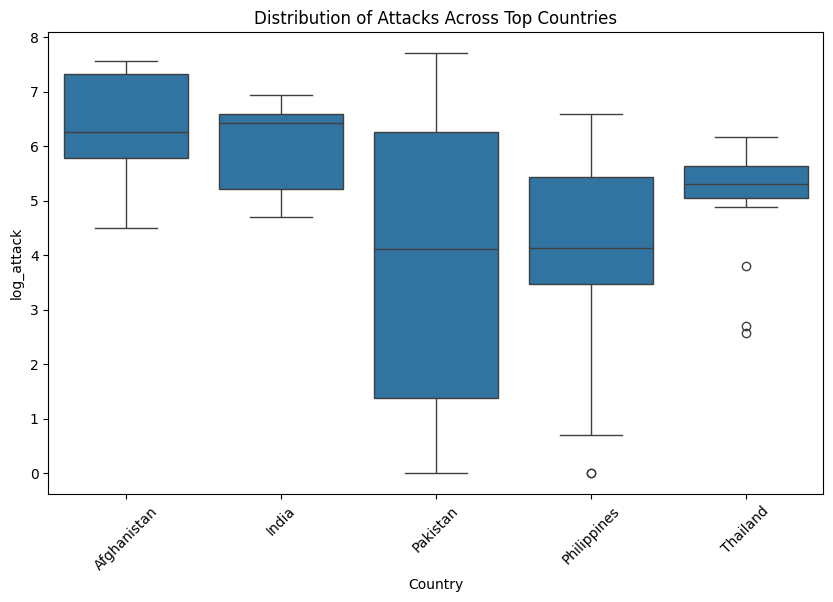

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Country', y='log_attack',
            data=df_reset[df_reset['Country'].isin(top_countries)])

plt.xticks(rotation=45)
plt.title("Distribution of Attacks Across Top Countries")
plt.show()

In [23]:
# ==============================
# STEP: Clean Data for OLS
# ==============================
import statsmodels.api as sm
import numpy as np

# Select variables
X = df[['log_gdp','log_population','Secondary_Enrollment',
        'Poverty_Headcount','Unemployment_Rate']]

y = df['Attacks']

# Combine X and y to clean together
data = pd.concat([X, y], axis=1)

# Remove inf and NaN
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

# Split back
X_clean = data.drop(columns=['Attacks'])
y_clean = data['Attacks']

# Add constant
X_clean = sm.add_constant(X_clean)

# ==============================
# OLS Model
# ==============================
ols_model = sm.OLS(y_clean, X_clean).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Attacks   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     42.09
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.44e-42
Time:                        21:55:25   Log-Likelihood:                -21317.
No. Observations:                3413   AIC:                         4.265e+04
Df Residuals:                    3407   BIC:                         4.268e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -192.6352 

In [24]:
# ==============================
# STEP 4: Simple OLS (Inference Preview)
# ==============================
import statsmodels.api as sm

# Avoid log(0) issue
df = df[df['GDP'] > 0]
df = df[df['Total_Population'] > 0]

X = df[['log_gdp','log_population','Secondary_Enrollment',
        'Poverty_Headcount','Unemployment_Rate']]

X = sm.add_constant(X)
y = df['Attacks']

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Attacks   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     42.09
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.44e-42
Time:                        21:55:26   Log-Likelihood:                -21317.
No. Observations:                3413   AIC:                         4.265e+04
Df Residuals:                    3407   BIC:                         4.268e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 -192.6352 

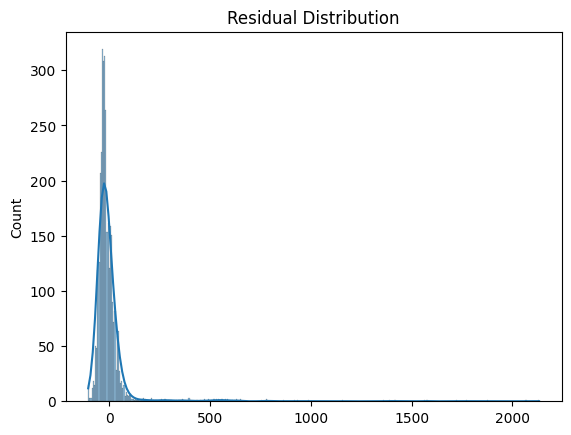

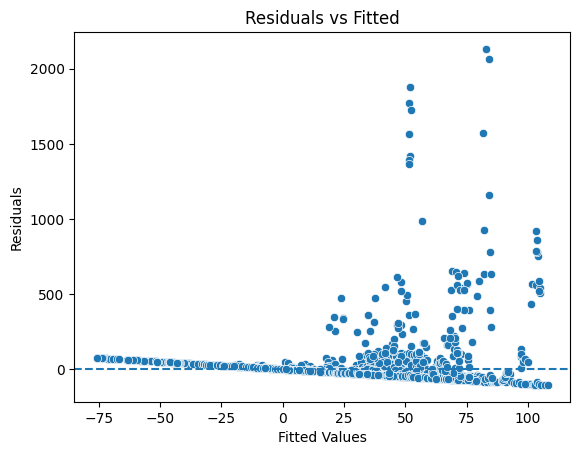

In [25]:
# ==============================
# STEP 5: Residual Analysis Plot
# ==============================
residuals = ols_model.resid

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.figure()
sns.scatterplot(x=ols_model.fittedvalues, y=residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

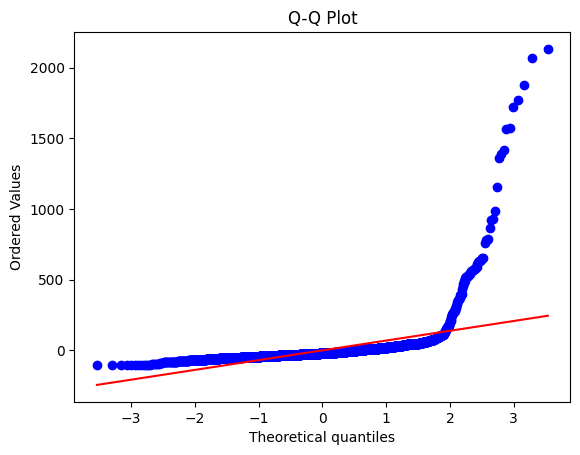

In [26]:
# ==============================
# STEP 6: Q-Q Plot (Normality Check)
# ==============================
import scipy.stats as stats

plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [27]:
# ==============================
# STEP 7: Heteroskedasticity Test (Breusch-Pagan)
# ==============================
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X)

print("\nBreusch-Pagan Test:")
print(f"LM Stat: {bp_test[0]:.4f}")
print(f"p-value: {bp_test[1]:.4f}")


Breusch-Pagan Test:
LM Stat: 52.6570
p-value: 0.0000


In [35]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Select variables
cols = ['Attacks','log_attack','log_gdp','log_population',
        'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']

data = df[cols].copy()

# Replace inf with NaN
data = data.replace([np.inf, -np.inf], np.nan)

# Drop missing safely
data = data.dropna()

print("Final data shape:", data.shape)

Final data shape: (3413, 7)


In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = data[['log_gdp','log_population','Secondary_Enrollment',
              'Poverty_Headcount','Unemployment_Rate']]

X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame()
vif_df['Variable'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) 
                 for i in range(X_vif.shape[1])]

print("\nVIF Results:")
print(vif_df)




VIF Results:
               Variable        VIF
0                 const  81.687955
1               log_gdp   1.052543
2        log_population   1.073600
3  Secondary_Enrollment   1.402507
4     Poverty_Headcount   1.392186
5     Unemployment_Rate   1.054245


In [40]:
# Define X and y
X = data[['log_gdp','log_population','Secondary_Enrollment',
          'Poverty_Headcount','Unemployment_Rate']]

y = data['log_attack']   # 🔥 USE log version (better)

# Add constant
X = sm.add_constant(X)

# Fit model with robust standard errors
ols_model = sm.OLS(y, X).fit(cov_type='HC3')

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_attack   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     166.6
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          6.75e-159
Time:                        22:02:32   Log-Likelihood:                -5898.9
No. Observations:                3413   AIC:                         1.181e+04
Df Residuals:                    3407   BIC:                         1.185e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -4.9193 

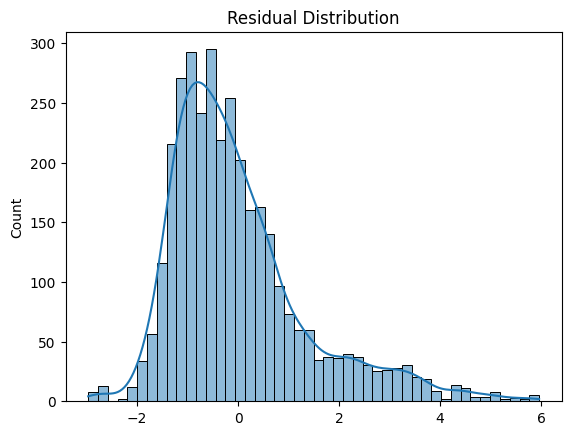

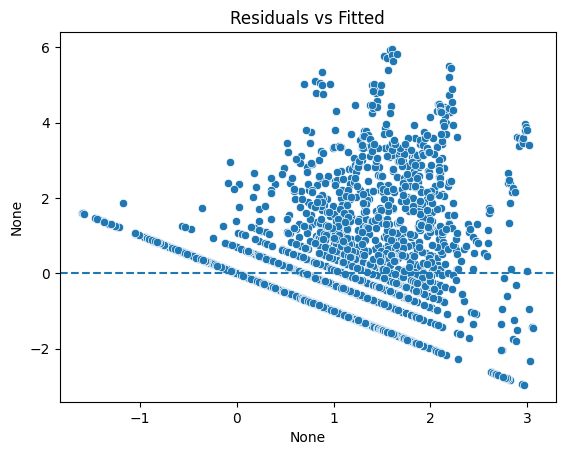

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = ols_model.resid

# Residual distribution
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# Residual vs fitted
sns.scatterplot(x=ols_model.fittedvalues, y=residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Fitted")
plt.show()

In [44]:
# ==============================
# PANEL SETUP
# ==============================
from linearmodels.panel import PanelOLS, RandomEffects

# Ensure panel structure
if not isinstance(df.index, pd.MultiIndex):
    df = df.set_index(['Country', 'Year'])

df = df.sort_index()

# Select final variables
cols = ['log_attack','Attacks','log_gdp','log_population',
        'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']

data = df[cols].replace([np.inf, -np.inf], np.nan).dropna()

print("Final panel data shape:", data.shape)

Final panel data shape: (3413, 7)


In [45]:
# ==============================
# FIXED EFFECTS MODEL
# ==============================
fe_model = PanelOLS.from_formula(
    'log_attack ~ log_gdp + log_population + Secondary_Enrollment + Poverty_Headcount + Unemployment_Rate + EntityEffects',
    data=data
)

fe_result = fe_model.fit(cov_type='clustered', cluster_entity=True)

print("\nFixed Effects Results:\n")
print(fe_result)


Fixed Effects Results:

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_attack   R-squared:                        0.0978
Estimator:                   PanelOLS   R-squared (Between):             -153.43
No. Observations:                3413   R-squared (Within):               0.0978
Date:                Mon, Mar 23 2026   R-squared (Overall):             -106.70
Time:                        22:06:57   Log-likelihood                   -4706.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      70.385
Entities:                         160   P-value                           0.0000
Avg Obs:                       21.331   Distribution:                  F(5,3248)
Min Obs:                       2.0000                                           
Max Obs:                       46.000   F-statistic (robust):             6.4840
   

In [46]:
# ==============================
# RANDOM EFFECTS MODEL
# ==============================
re_model = RandomEffects.from_formula(
    'log_attack ~ log_gdp + log_population + Secondary_Enrollment + Poverty_Headcount + Unemployment_Rate',
    data=data
)

re_result = re_model.fit()

print("\nRandom Effects Results:\n")
print(re_result)


Random Effects Results:

                        RandomEffects Estimation Summary                        
Dep. Variable:             log_attack   R-squared:                        0.0723
Estimator:              RandomEffects   R-squared (Between):              0.3291
No. Observations:                3413   R-squared (Within):               0.0491
Date:                Mon, Mar 23 2026   R-squared (Overall):              0.2823
Time:                        22:07:18   Log-likelihood                   -4899.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      53.138
Entities:                         160   P-value                           0.0000
Avg Obs:                       21.331   Distribution:                  F(5,3408)
Min Obs:                       2.0000                                           
Max Obs:                       46.000   F-statistic (robust):             53.138
  

In [47]:
# ==============================
# HAUSMAN TEST
# ==============================
from linearmodels.panel import compare

print("\nHausman Test (FE vs RE):\n")
print(compare({'FE': fe_result, 'RE': re_result}))


Hausman Test (FE vs RE):

                     Model Comparison                    
                                     FE                RE
---------------------------------------------------------
Dep. Variable                log_attack        log_attack
Estimator                      PanelOLS     RandomEffects
No. Observations                   3413              3413
Cov. Est.                     Clustered        Unadjusted
R-squared                        0.0978            0.0723
R-Squared (Within)               0.0978            0.0491
R-Squared (Between)             -153.43            0.3291
R-Squared (Overall)             -106.70            0.2823
F-statistic                      70.385            53.138
P-value (F-stat)                 0.0000            0.0000
======================     ============   ===============
log_gdp                         -0.0359           -0.0546
                              (-1.5388)         (-2.4602)
log_population                   1.2833      

In [48]:
# ==============================
# POISSON MODEL
# ==============================
import statsmodels.api as sm

X = data[['log_gdp','log_population','Secondary_Enrollment',
          'Poverty_Headcount','Unemployment_Rate']]

X = sm.add_constant(X)
y = data['Attacks']

poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

print("\nPoisson Model Results:\n")
print(poisson_model.summary())


Poisson Model Results:

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 3413
Model:                            GLM   Df Residuals:                     3407
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4611e+05
Date:                Mon, 23 Mar 2026   Deviance:                   2.8661e+05
Time:                        22:07:45   Pearson chi2:                 9.32e+05
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const  

In [49]:
# ==============================
# NEGATIVE BINOMIAL MODEL
# ==============================
nb_model = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()

print("\nNegative Binomial Results:\n")
print(nb_model.summary())


Negative Binomial Results:

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                 3413
Model:                            GLM   Df Residuals:                     3407
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10459.
Date:                Mon, 23 Mar 2026   Deviance:                       11841.
Time:                        22:08:12   Pearson chi2:                 4.83e+04
No. Iterations:                    17   Pseudo R-squ. (CS):             0.9029
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
con

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [50]:
# ==============================
# OVERDISPERSION CHECK
# ==============================
mean_attacks = y.mean()
var_attacks = y.var()

print("\nOverdispersion Check:")
print(f"Mean: {mean_attacks:.4f}")
print(f"Variance: {var_attacks:.4f}")


Overdispersion Check:
Mean: 24.7876
Variance: 16550.7775


In [ ]:
#(Arellano-Bond)

from linearmodels.panel import PanelOLS
from linearmodels.panel import FirstDifferenceOLS

# Create lag
df['lag_attack'] = df.groupby(level=0)['log_attack'].shift(1)

data_dyn = df[['log_attack','lag_attack','log_gdp','log_population',
               'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']].dropna()

model_dyn = PanelOLS.from_formula(
    'log_attack ~ lag_attack + log_gdp + log_population + Secondary_Enrollment + Poverty_Headcount + Unemployment_Rate + EntityEffects',
    data=data_dyn
)

result_dyn = model_dyn.fit(cov_type='clustered', cluster_entity=True)

print(result_dyn)

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_attack   R-squared:                        0.4819
Estimator:                   PanelOLS   R-squared (Between):             -18.892
No. Observations:                3253   R-squared (Within):               0.4819
Date:                Mon, Mar 23 2026   R-squared (Overall):             -13.049
Time:                        22:09:56   Log-likelihood                   -3597.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      478.52
Entities:                         160   P-value                           0.0000
Avg Obs:                       20.331   Distribution:                  F(6,3087)
Min Obs:                       1.0000                                           
Max Obs:                       45.000   F-statistic (robust):             113.53
                            

In [57]:
# Recreate clean dataset
data = df[['log_attack','log_gdp','log_population',
           'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']].copy()

data = data.replace([np.inf, -np.inf], np.nan).dropna()

# Create interaction HERE
data['poverty_unemp'] = data['Poverty_Headcount'] * data['Unemployment_Rate']

from linearmodels.panel import PanelOLS

model_interaction = PanelOLS.from_formula(
    'log_attack ~ log_gdp + log_population + Secondary_Enrollment + Poverty_Headcount + Unemployment_Rate + poverty_unemp + EntityEffects',
    data=data
)

print(model_interaction.fit(cov_type='clustered', cluster_entity=True))

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_attack   R-squared:                        0.1028
Estimator:                   PanelOLS   R-squared (Between):             -153.23
No. Observations:                3413   R-squared (Within):               0.1028
Date:                Mon, Mar 23 2026   R-squared (Overall):             -106.46
Time:                        22:16:22   Log-likelihood                   -4697.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      61.979
Entities:                         160   P-value                           0.0000
Avg Obs:                       21.331   Distribution:                  F(6,3247)
Min Obs:                       2.0000                                           
Max Obs:                       46.000   F-statistic (robust):             5.9063
                            

In [59]:
# Recreate clean dataset
data = df[['log_attack','log_gdp','log_population',
           'Secondary_Enrollment','Poverty_Headcount','Unemployment_Rate']].copy()

data = data.replace([np.inf, -np.inf], np.nan).dropna()

# Create squared term HERE
data['gdp_sq'] = data['log_gdp'] ** 2

from linearmodels.panel import PanelOLS

model_nonlinear = PanelOLS.from_formula(
    'log_attack ~ log_gdp + gdp_sq + log_population + Secondary_Enrollment + EntityEffects',
    data=data
)

print(model_nonlinear.fit(cov_type='clustered', cluster_entity=True))

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_attack   R-squared:                        0.0953
Estimator:                   PanelOLS   R-squared (Between):             -127.96
No. Observations:                3413   R-squared (Within):               0.0953
Date:                Mon, Mar 23 2026   R-squared (Overall):             -88.963
Time:                        22:20:01   Log-likelihood                   -4711.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      85.565
Entities:                         160   P-value                           0.0000
Avg Obs:                       21.331   Distribution:                  F(4,3249)
Min Obs:                       2.0000                                           
Max Obs:                       46.000   F-statistic (robust):             8.8602
                            

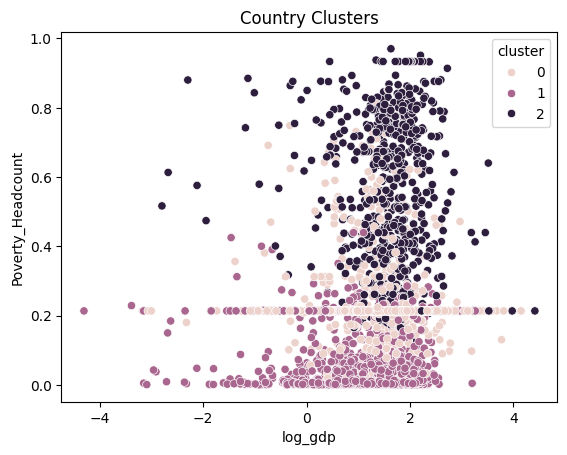


Cluster Profiles:

          log_gdp  log_population  Secondary_Enrollment  Poverty_Headcount  \
cluster                                                                      
0        1.498186       14.655489             38.241850           0.232033   
1        1.092315       15.433081             94.578420           0.083194   
2        1.629031       17.323535             38.117198           0.475794   

         Unemployment_Rate  
cluster                     
0                12.032232  
1                 6.920351  
2                 4.331099  


In [65]:
# ==============================
# STEP 1: Select Features
# ==============================
features = df[['log_gdp','log_population','Secondary_Enrollment',
               'Poverty_Headcount','Unemployment_Rate']].copy()

# Clean data
features = features.replace([np.inf, -np.inf], np.nan).dropna()

# ==============================
# STEP 2: Standardize Data (IMPORTANT)
# ==============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# ==============================
# STEP 3: Apply KMeans
# ==============================
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
features['cluster'] = kmeans.fit_predict(features_scaled)

# ==============================
# STEP 4: Visualization
# ==============================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(x=features['log_gdp'],
                y=features['Poverty_Headcount'],
                hue=features['cluster'])

plt.title("Country Clusters")
plt.xlabel("log_gdp")
plt.ylabel("Poverty_Headcount")
plt.show()

# ==============================
# STEP 5: Cluster Summary
# ==============================
print("\nCluster Profiles:\n")
print(features.groupby('cluster').mean())

In [55]:
#Granger Causality

from statsmodels.tsa.stattools import grangercausalitytests

temp = df.reset_index()[['Year','Attacks','GDP']].dropna()

grangercausalitytests(temp[['Attacks','GDP']], maxlag=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.1850  , p=0.0074  , df_denom=3409, df_num=1
ssr based chi2 test:   chi2=7.1913  , p=0.0073  , df=1
likelihood ratio test: chi2=7.1838  , p=0.0074  , df=1
parameter F test:         F=7.1850  , p=0.0074  , df_denom=3409, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=9.4701  , p=0.0001  , df_denom=3406, df_num=2
ssr based chi2 test:   chi2=18.9680 , p=0.0001  , df=2
likelihood ratio test: chi2=18.9154 , p=0.0001  , df=2
parameter F test:         F=9.4701  , p=0.0001  , df_denom=3406, df_num=2


{np.int64(1): ({'ssr_ftest': (np.float64(7.184995291531307),
    np.float64(0.007386953444604144),
    np.float64(3409.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(7.19131825600024),
    np.float64(0.007325714218071049),
    np.int64(1)),
   'lrtest': (np.float64(7.183750479336595),
    np.float64(0.007356676680643463),
    np.int64(1)),
   'params_ftest': (np.float64(7.184995291532779),
    np.float64(0.007386953444599289),
    np.float64(3409.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(9.470085357146258),
    np.float64(7.917485310570813e-05),
    np.float64(3406.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(18.967974840414495),
    np.float64(7.606004831765608e-05),
    np.int64(2)),
   'lrtest': (np.float64(18.91543074628862),
    np.float64(7.808478197762625e-05),
    np.int64(2)),
   'params_ftest': (np.float64(9.470085357144036),
    np.float64(7.917485310586735e-05),
    np.float64(3406.0),
    2.0)},
   array([[0., 0., 1.,

In [56]:
#quantile regression

import statsmodels.formula.api as smf

model_q = smf.quantreg('Attacks ~ log_gdp + log_population + Secondary_Enrollment', df.reset_index())
res_q = model_q.fit(q=0.5)

print(res_q.summary())

                         QuantReg Regression Results                          
Dep. Variable:                Attacks   Pseudo R-squared:             0.002160
Model:                       QuantReg   Bandwidth:                      0.6680
Method:                 Least Squares   Sparsity:                        2.888
Date:                Mon, 23 Mar 2026   No. Observations:                 3413
Time:                        22:14:14   Df Residuals:                     3409
                                        Df Model:                            3
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -3.7293      0.206    -18.113      0.000      -4.133      -3.326
log_gdp                  0.0417      0.029      1.442      0.150      -0.015       0.098
log_population           0.2529      0.012     20.846      0.000       0.229       0.277
Se